<a href="https://colab.research.google.com/github/rirfan3689/CSCI323-Spam-Detection/blob/main/notebooks/10_spamassassin_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import numpy as np
from scipy.sparse import load_npz
import pandas as pd

uploaded = files.upload()  # Upload sa_X_train.npz, sa_X_test.npz,
                           # sa_y_train.npy, sa_y_test.npy

X_train = load_npz('sa_X_train.npz')
X_test = load_npz('sa_X_test.npz')
y_train = np.load('sa_y_train.npy', allow_pickle=True)
y_test = np.load('sa_y_test.npy', allow_pickle=True)

print("Data loaded successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Saving sa_X_test.npz to sa_X_test.npz
Saving sa_X_train.npz to sa_X_train.npz
Saving sa_y_test.npy to sa_y_test.npy
Saving sa_y_train.npy to sa_y_train.npy
Data loaded successfully!
X_train shape: (4263, 5000)
X_test shape: (1066, 5000)


In [2]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import json

print("Libraries loaded!")

Libraries loaded!


In [3]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, pos_label='spam'),
        'recall': recall_score(y_test, y_pred, pos_label='spam'),
        'f1': f1_score(y_test, y_pred, pos_label='spam'),
        'y_pred': y_pred.tolist()
    }

    print(f"=== {name} Results ===")
    print(f"Accuracy:  {results[name]['accuracy']:.4f}")
    print(f"Precision: {results[name]['precision']:.4f}")
    print(f"Recall:    {results[name]['recall']:.4f}")
    print(f"F1 Score:  {results[name]['f1']:.4f}")

print("\nAll models trained!")


Training Naive Bayes...
=== Naive Bayes Results ===
Accuracy:  0.9822
Precision: 0.9969
Recall:    0.9467
F1 Score:  0.9712

Training Logistic Regression...
=== Logistic Regression Results ===
Accuracy:  0.9841
Precision: 0.9969
Recall:    0.9527
F1 Score:  0.9743

Training SVM...
=== SVM Results ===
Accuracy:  0.9953
Precision: 0.9970
Recall:    0.9882
F1 Score:  0.9926

Training Random Forest...
=== Random Forest Results ===
Accuracy:  0.9906
Precision: 0.9940
Recall:    0.9763
F1 Score:  0.9851

All models trained!


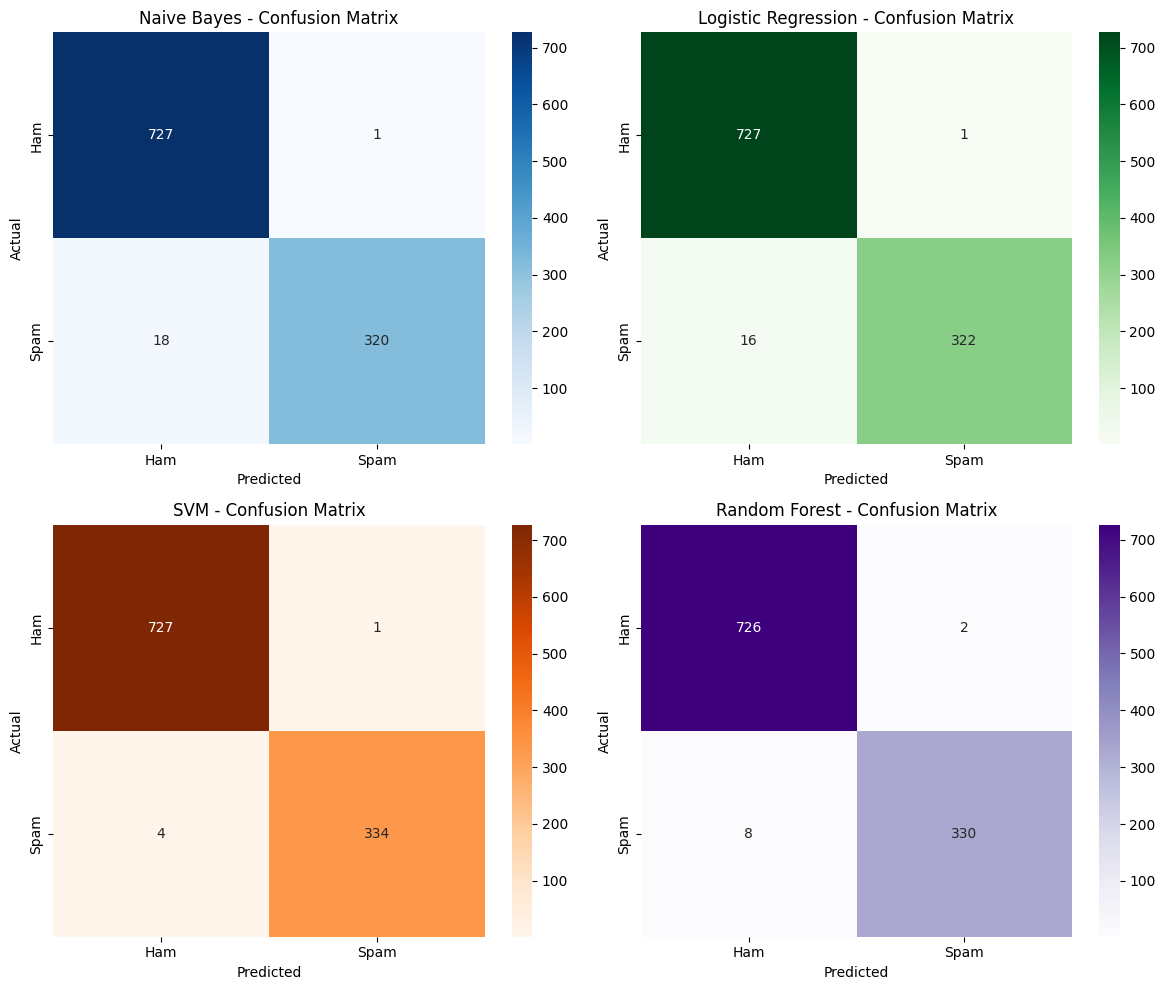

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

colors = ['Blues', 'Greens', 'Oranges', 'Purples']

for i, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['y_pred'],
                         labels=['ham', 'spam'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=colors[i],
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'],
                ax=axes[i])
    axes[i].set_title(f'{name} - Confusion Matrix')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('sa_confusion_matrices.png')
plt.show()

In [5]:
import pandas as pd

df_results = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': f"{r['accuracy']*100:.2f}%",
        'Precision': f"{r['precision']*100:.2f}%",
        'Recall': f"{r['recall']*100:.2f}%",
        'F1 Score': f"{r['f1']*100:.2f}%"
    }
    for name, r in results.items()
])

print("=== SpamAssassin Model Comparison ===")
print(df_results.to_string(index=False))

=== SpamAssassin Model Comparison ===
              Model Accuracy Precision Recall F1 Score
        Naive Bayes   98.22%    99.69% 94.67%   97.12%
Logistic Regression   98.41%    99.69% 95.27%   97.43%
                SVM   99.53%    99.70% 98.82%   99.26%
      Random Forest   99.06%    99.40% 97.63%   98.51%


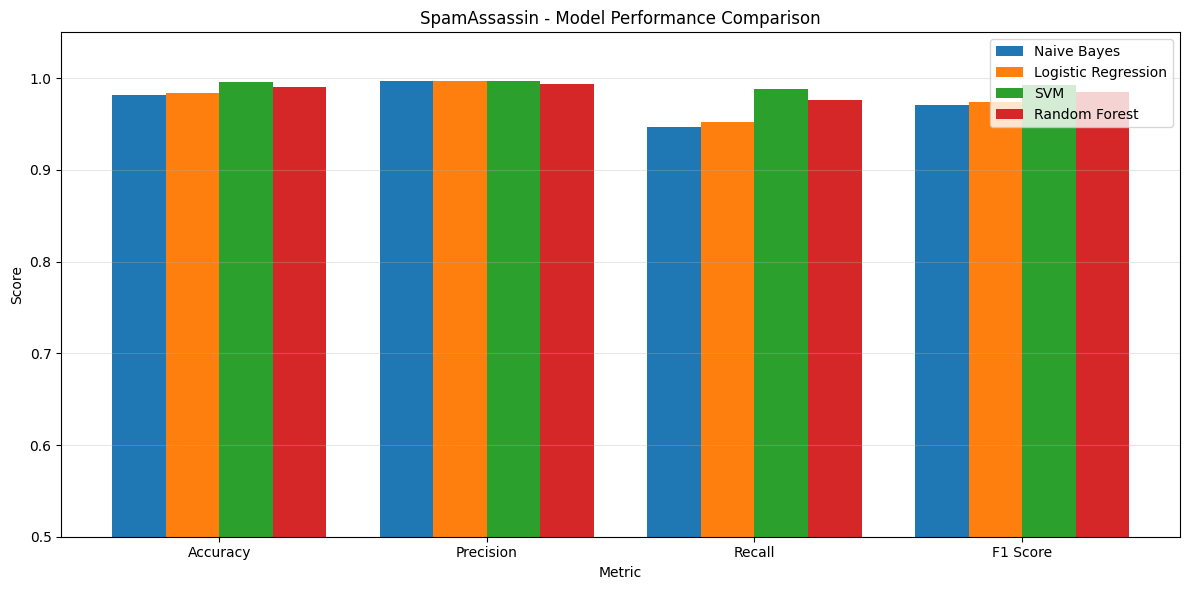

In [6]:
metrics = ['accuracy', 'precision', 'recall', 'f1']
model_names = list(results.keys())
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

for i, name in enumerate(model_names):
    values = [results[name][m] for m in metrics]
    ax.bar(x + i * width, values, width, label=name)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('SpamAssassin - Model Performance Comparison')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1 Score'])
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('sa_model_comparison.png')
plt.show()

In [7]:
# Remove y_pred before saving to JSON
sa_results = {}
for name, r in results.items():
    sa_results[name] = {
        'model': r['model'],
        'accuracy': r['accuracy'],
        'precision': r['precision'],
        'recall': r['recall'],
        'f1': r['f1']
    }

with open('sa_results.json', 'w') as f:
    json.dump(sa_results, f)

print("Results saved!")
print(sa_results)

Results saved!
{'Naive Bayes': {'model': 'Naive Bayes', 'accuracy': 0.9821763602251408, 'precision': 0.9968847352024922, 'recall': 0.9467455621301775, 'f1': 0.9711684370257967}, 'Logistic Regression': {'model': 'Logistic Regression', 'accuracy': 0.9840525328330206, 'precision': 0.9969040247678018, 'recall': 0.9526627218934911, 'f1': 0.9742813918305597}, 'SVM': {'model': 'SVM', 'accuracy': 0.9953095684803002, 'precision': 0.9970149253731343, 'recall': 0.9881656804733728, 'f1': 0.9925705794947994}, 'Random Forest': {'model': 'Random Forest', 'accuracy': 0.9906191369606003, 'precision': 0.9939759036144579, 'recall': 0.9763313609467456, 'f1': 0.9850746268656716}}
